In [3]:
import json
def load_raw_comments(filepath='comments.json'):
    comments = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            # Skip replies if flagged as a reply
            if obj.get('reply') is True:
                continue
            # Append the comment text (if available) or the whole object
            comments.append(obj.get('text', obj))
    return comments

raw_comments = load_raw_comments()
print(f"Loaded {len(raw_comments)} potential comment lines.")
print(raw_comments[:5])

Loaded 50 potential comment lines.
['What an absolutely beautiful and emotional short documentary! 🦓✨\nBBC Earth always has a special way of capturing the soul of wildlife, but this zebra journey feels particularly touching. The way the team follows her through danger, migration, and finally forming her own family is incredibly moving.\n\nThe cinematography is stunning — every frame feels like a painting, from the dusty plains to the gentle close-ups that reveal her courage and resilience. 🌍💛\nIt’s amazing how you can portray not just survival, but also hope, connection, and the quiet strength of an animal often overlooked.\n\nThank you for telling these powerful stories with respect, beauty, and heart. Truly inspiring work! 👏📽🌿', 'It’s a nice wildlife video. Greetings from Botswana 😊', "It's a good thing the team's aircraft served a purpose for quick communication and a location isolating system.", 'Beautiful footage — it’s incredible to see the Nxai Pan zebra migration from the air. 

In [4]:
def load_vtt_captions(filepath='zebra.vtt'):
    captions = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Ignore empty lines
            if not line:
                continue
            # Ignore metadata lines such as timestamps, sequence numbers, and header
            if '-->' in line or line.isdigit() or 'WEBVTT' in line or line.startswith('Kind:') or line.startswith('Language:'):
                continue
            captions.append(line)
    return captions

raw_captions = load_vtt_captions()
print(f"Loaded {len(raw_captions)} caption lines.")

Loaded 155 caption lines.


Histogram of Lengths (Captions vs. Comments)

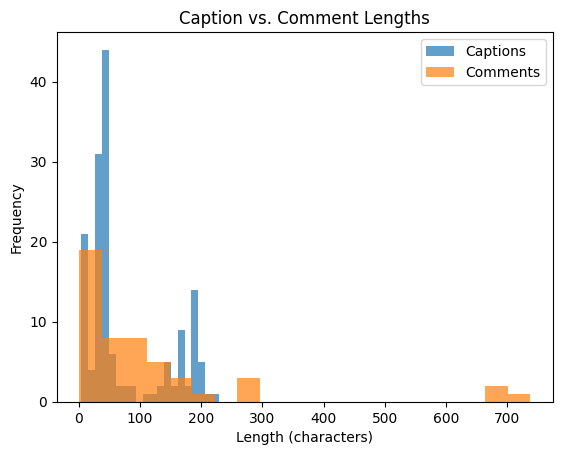

In [5]:
import matplotlib.pyplot as plt
caption_lengths = [len(x) for x in raw_captions]
comment_lengths = [len(x) for x in raw_comments]
plt.hist(caption_lengths, bins=20, alpha=0.7, label='Captions')
plt.hist(comment_lengths, bins=20, alpha=0.7, label='Comments')
plt.legend()
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.title('Caption vs. Comment Lengths')
plt.show()

Vocabulary Diversity (Type-Token Ratio)

In [6]:
def type_token_ratio(lines):
	if not lines:
		return 0
	words = [word.lower() for line in lines for word in line.split()]
	unique = set(words)
	return len(unique) / len(words) if words else 0

print("Caption TTR:", type_token_ratio(raw_captions))
print("Comment TTR:", type_token_ratio(raw_comments))

Caption TTR: 0.5420944558521561
Comment TTR: 0.5396825396825397


In [7]:
from collections import Counter
stopwords = set([
    'the', 'and', 'a', 'is', 'in', 'to', 'of', 'that', 'it', 'on',
    'for', 'with', 'as', 'this', 'was', 'but', 'are', 'not', 'be', 'at', 'by',
    'an', 'if', 'or', 'from', 'so', 'we'
])
def top_n_words(lines, n=20):
    words = [word.lower() for line in lines for word in line.split() if
             word.lower() not in stopwords]
    return Counter(words).most_common(n)
print("Top 20 caption words:", top_n_words(raw_captions))
print("Top 20 comment words:", top_n_words(raw_comments))

Top 20 caption words: [('[music]', 13), ('her', 12), ('she', 10), ('zebra', 6), ('family', 6), ("she's", 6), ('just', 6), ('time', 6), ('new', 6), ('like', 6), ('have', 6), ('after', 4), ('first', 4), ('grass', 4), ('part', 4), ('group', 4), ('there', 4), ('know', 4), ('looks', 4), ('gps', 4)]
Top 20 comment words: [('i', 13), ('you', 11), ('zebra', 9), ('beautiful', 8), ('bbc', 6), ('journey', 6), ('like', 6), ('nature', 6), ('earth', 5), ('way', 5), ('her', 5), ('how', 5), ('just', 5), ('zebras', 5), ('no', 5), ('when', 5), ('who', 5), ('always', 4), ('it’s', 4), ('migration', 4)]


Caption lines: 155 Comments: 50


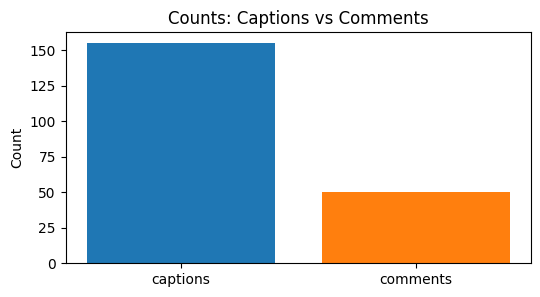

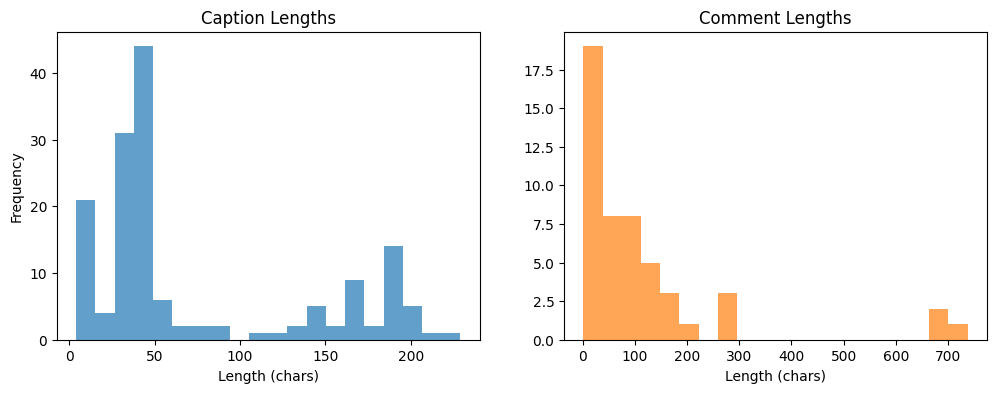

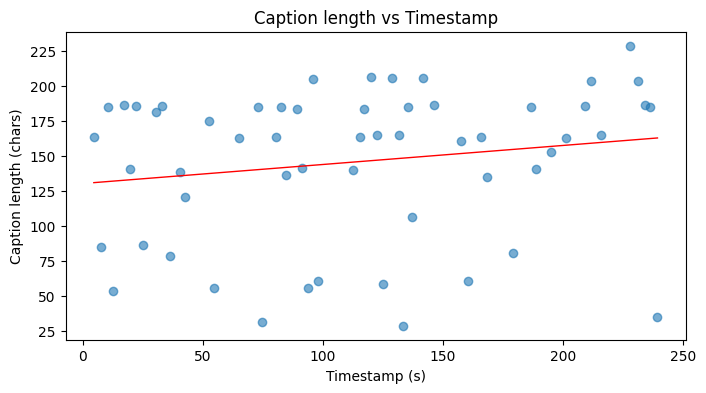

No 'likes' metadata found for comments — skipping comment length vs likes scatter.
Caption len vs time correlation: 0.1772
Mean caption length first 5 lines: 135.0, last 5 lines: 168.0
Comments <= 10 chars: 7 (14.0%)
Comment length median: 66.5, mean: 117.0
No comment timestamps available — cannot plot commenting activity over time.


In [8]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

# Build captions DataFrame with lengths and timestamps
def parse_timestamp(s):
    if not isinstance(s, str):
        return np.nan
    m = re.search(r'(\d{2}:\d{2}:\d{2}\.\d+|\d{2}:\d{2}\.\d+)', s)
    if not m:
        return np.nan
    ts = m.group(0)
    parts = ts.split(':')
    try:
        if len(parts) == 3:
            h, mnt, sec = int(parts[0]), int(parts[1]), float(parts[2])
            return h * 3600 + mnt * 60 + sec
        elif len(parts) == 2:
            mnt, sec = int(parts[0]), float(parts[1])
            return mnt * 60 + sec
    except Exception:
        return np.nan
    return np.nan

df_caps = pd.DataFrame({'text': raw_captions, 'len': caption_lengths})
df_caps['timestamp_s'] = df_caps['text'].apply(parse_timestamp)
df_caps['minute'] = df_caps['timestamp_s'].apply(lambda x: np.nan if pd.isna(x) else int(x // 60))

# Build comments DataFrame (extract likes and created time if present)
def extract_comment_meta(x):
    if isinstance(x, str):
        return x, np.nan, pd.NaT
    if isinstance(x, dict):
        text = x.get('text') or x.get('message') or x.get('body')
        likes = x.get('likes') or x.get('like_count') or x.get('upvotes') or x.get('score')
        created = x.get('created_utc') or x.get('created') or x.get('timestamp') or x.get('time')
        return text, likes, created
    return str(x), np.nan, pd.NaT

rows = [extract_comment_meta(c) for c in raw_comments]
df_comments = pd.DataFrame(rows, columns=['text', 'likes', 'created'])
df_comments['len'] = [len(t) if isinstance(t, str) else 0 for t in df_comments['text']]

# Normalize likes to numeric if any exist
df_comments['likes'] = pd.to_numeric(df_comments['likes'], errors='coerce')

# Parse created timestamps to datetime if numeric/ISO (best-effort)
def parse_created(c):
    if pd.isna(c):
        return pd.NaT
    if isinstance(c, (int, float)):
        try:
            return pd.to_datetime(c, unit='s', utc=True)
        except Exception:
            return pd.NaT
    if isinstance(c, str):
        try:
            return pd.to_datetime(c, utc=True)
        except Exception:
            try:
                return pd.to_datetime(float(c), unit='s', utc=True)
            except Exception:
                return pd.NaT
    return pd.NaT

df_comments['created_dt'] = df_comments['created'].apply(parse_created)
df_comments['minute'] = df_comments['created_dt'].dt.floor('min')

# Basic counts
print("Caption lines:", len(df_caps), "Comments:", len(df_comments))

# 1) Basic visualizations
plt.figure(figsize=(6, 3))
plt.bar(['captions', 'comments'], [len(df_caps), len(df_comments)], color=['tab:blue', 'tab:orange'])
plt.title('Counts: Captions vs Comments')
plt.ylabel('Count')
plt.show()

# Caption length column already present: df_caps['len']
# Histograms (length distributions)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_caps['len'].dropna(), bins=20, alpha=0.7, color='tab:blue')
axes[0].set_title('Caption Lengths')
axes[0].set_xlabel('Length (chars)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_comments['len'].dropna(), bins=20, alpha=0.7, color='tab:orange')
axes[1].set_title('Comment Lengths')
axes[1].set_xlabel('Length (chars)')
plt.show()

# Scatter: caption length vs timestamp
mask = df_caps['timestamp_s'].notna()
plt.figure(figsize=(8, 4))
plt.scatter(df_caps.loc[mask, 'timestamp_s'], df_caps.loc[mask, 'len'], alpha=0.6)
plt.xlabel('Timestamp (s)')
plt.ylabel('Caption length (chars)')
plt.title('Caption length vs Timestamp')
# Trendline if possible
if mask.sum() > 1:
    z = np.polyfit(df_caps.loc[mask, 'timestamp_s'], df_caps.loc[mask, 'len'], 1)
    xs = np.linspace(df_caps.loc[mask, 'timestamp_s'].min(), df_caps.loc[mask, 'timestamp_s'].max(), 200)
    plt.plot(xs, np.polyval(z, xs), color='red', linewidth=1)
plt.show()

# Scatter: comment length vs likes (only if likes metadata present)
if df_comments['likes'].notna().any():
    plt.figure(figsize=(6, 4))
    plt.scatter(df_comments['likes'].fillna(0), df_comments['len'], alpha=0.6)
    plt.xlabel('Likes')
    plt.ylabel('Comment length (chars)')
    plt.title('Comment length vs Likes')
    plt.show()
else:
    print("No 'likes' metadata found for comments — skipping comment length vs likes scatter.")

# 2) Key Questions & analyses

# a) Longer captions near beginning/end?
caps_with_ts = df_caps.dropna(subset=['timestamp_s'])
if len(caps_with_ts) > 1:
    corr = caps_with_ts['len'].corr(caps_with_ts['timestamp_s'])
    # Compare mean of first 10% vs last 10%
    n = len(caps_with_ts)
    k = max(1, int(n * 0.1))
    sorted_caps = caps_with_ts.sort_values('timestamp_s')
    first_mean = sorted_caps.head(k)['len'].mean()
    last_mean = sorted_caps.tail(k)['len'].mean()
    print(f"Caption len vs time correlation: {corr:.4f}")
    print(f"Mean caption length first {k} lines: {first_mean:.1f}, last {k} lines: {last_mean:.1f}")
else:
    print("Not enough timestamped captions to analyze caption length over time.")

# b) Do comments show many short messages?
short_thresh = 10
num_short = (df_comments['len'] <= short_thresh).sum()
pct_short = num_short / len(df_comments) if len(df_comments) > 0 else 0
print(f"Comments <= {short_thresh} chars: {num_short} ({pct_short:.1%})")
print(f"Comment length median: {df_comments['len'].median():.1f}, mean: {df_comments['len'].mean():.1f}")

# c) Peaks in commenting activity vs caption timestamps (by minute)
if df_comments['minute'].notna().any():
    counts = df_comments.groupby('minute').size().rename('count')
    fig, ax = plt.subplots(figsize=(12, 4))
    counts.plot(ax=ax, marker='o')
    ax.set_title('Comments per minute (by created timestamp)')
    ax.set_ylabel('Comments')
    ax.set_xlabel('Minute')
    # overlay caption timestamps as vertical lines if available
    if df_caps['minute'].notna().any():
        for m in sorted(df_caps['minute'].dropna().unique()):
            ax.axvline(pd.to_datetime(m, unit='m', origin='unix'), color='red', alpha=0.05)
    plt.show()
else:
    print("No comment timestamps available — cannot plot commenting activity over time.")